# Metamerism Detection via SMT Solvers

In this notebook, we will use Z3 to explore the physics of color perception and build mathematical constraints to find metamers—objects that share identical perceived color values under a given light source despite having entirely different reflectance spectrums.

**Instructions:**
1. To get started, click on File on the top left and click "Save a copy in Drive."
This will give you an editable version of this document that you can use.
2. If you press `CMD`+`Enter` it runs the cell, and if you press `Shift`+`Enter` it runs the cell and goes to the next one.
3. Make sure you run all cells as you go through the notebook; some cells will not work properly unless the previous one
has been run too.
4. If you disconnect or are inactive for some time you should run all of the cells again.

## 0. Preliminaries (you should run this cell but there is no need to read it)

In [1]:
!pip install z3-solver
!pip install git+https://github.com/crrivero/FormalMethodsTasting.git#subdirectory=core
from z3 import *
from tofmcore import showSolver, gaussian, generate_illuminant, plot_illuminant, generate_reflectant, plot_reflectant, generate_and_plot_ERL, generate_sensor, plot_sensor, plot_two_reflectants
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
clear_output()

## Encoding constraints in Z3

The goal of this notebook is to teach you about formal methods;
particularly, how you can use existing formal verification tools
(in this case, Z3) to analyze and solve your own problems.
Before we get started, let's look at some basic things we can do with Z3.

### Reals

Let's use Z3 to solve problems involving real numbers. Let's start with something simple: find $x$ such that

$$2x + 5 = 15$$

In [2]:
# Initialize variables

x = Real('x') # declairing that x is a real number named 'x'

# Initialize Z3 solver
s = Solver()

s.add( 2*x + 5 == 15 ) # add the equation

print(s)
print(s.check())
print(s.model())

[2*x + 5 == 15]
sat
[x = 5]


Now let's try to check whether that's the only solution. We can do this by adding the following constraint to the solver:

$$x \not= 5$$

If the solver returns "**unsat**" then $x=5$ is the only solution.
Try it yourself by completing the code in the cell below.

In [3]:
s.add( x == 5 ) # REPLACE THIS LINE
s.check()

sat

# Metamerism Detection

Metamerisms refer to a phenomenon where two objects look like the same color under a certain light, but are in reality different colors. The two objects that cause a metamerism are referred to as metamers. We can model metamerisms mathematically as such:

Firstly, there's the **illuminant**, which shines light on our objects, and its corresponding illuminance function, $e(\lambda)$, where $\lambda$ is a wavelength. $e(\lambda)$ tells us how powerfully the illuminant emits a given wavelength, scaled between $0$ and $1$. For example, a heat lamp would have high power (and thus a larger $e(\lambda)$) for $\lambda$'s around $550$ to $700$, and close to no power for $\lambda < 500$. The sun's $e(\lambda)$ is maximal for $400 \leq \lambda \leq 500$, but also emits across the whole visible spectrum. Our example illuminant will be a simplified, simulated daylight.

When calculating metamerisms, we don't want to just know illuminance at one wavelength, however. We'd like to assess the sum total color of the illuminance across the given sensor's entire visible spectrum. So, we construct a vector $E$ that captures the power of the illuminant across the range of relevant $\lambda$. For our example, our sensor will be the human eye, and so our range of $\lambda$'s will be between $380$ and $700$, with a sampling width of $5$ nm. So, $\boldsymbol{\lambda} = [380, 385, 390, \ldots, 690, 695, 700]$.

Let's get to modeling this in code.

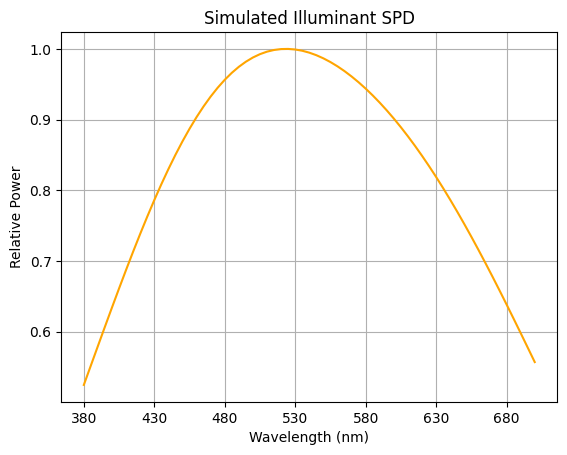

In [4]:
# Wavelengths
wl_min = 380
wl_max = 700
wl = np.arange(wl_min, wl_max+1, 5) # Wavelengths 5nm apart

# Simulated illuminant, using Gaussian distribution
E = generate_illuminant(wl)

# Plotting the illuminant's SPD
plot_illuminant(wl, E)

Next, there's the **reflectant**, which is what the light illuminant's light is shining off of, i.e. our object. It has a corresponding reflectance function $r(\lambda)$, which tells us how powerfully the reflectant reflects a certain wavelength. This is very similar to illuminance, but instead of describing how something emits its own light, it describes how it reflects incoming light. Similar to our construction of $E$, we will construct a vector of reflectances $R$ over our wavelength range.

In code:

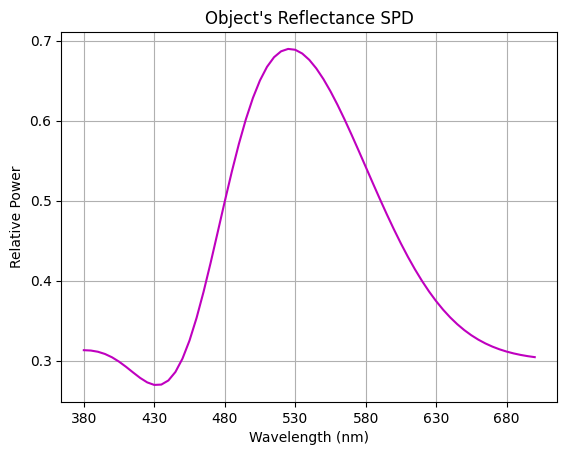

In [5]:
# Some reflectant, nothing in particular
# Labeled r1 b/c we'll introduce another one later
R1 = generate_reflectant(wl)

# Plotting the object's reflectance SPD
plot_reflectant(wl, R1)

If we multiply these two objects together, we get the resultant power for a given wavelength after being emitted from its illuminant and reflected of our object. Mathmematically, let $l(\lambda) = e(\lambda)r(\lambda)$, and we can vectorize $l(\lambda)$ into $L$ in the same way we did with $E$ and $R$.

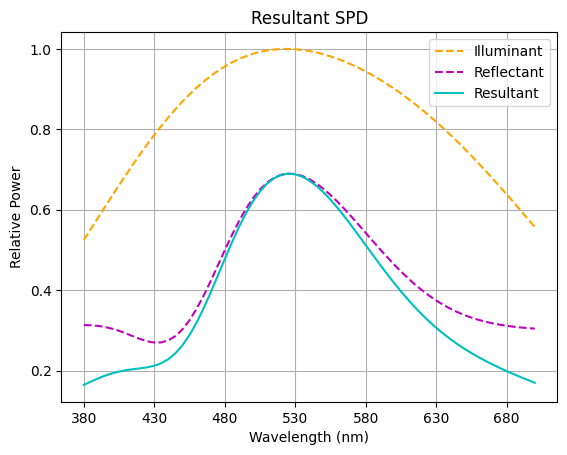

In [6]:
L = generate_and_plot_ERL(wl, E, R1)

We can see that the reflectant just scales down the illuminance by some factor based on the wavelength.

The last thing we have to model is the **sensor**, which will take in the resultant light from above and interpret it into a single color. To represent the sensor, we use $s(\lambda)$, which outputs a $1 \times k$ vector, where $k$ is the number of channels in the sensor and the $i$th entry in the vector represents how senstive the $i$th channel is to the given wavelength $\lambda$. For human eyes, which have three cones, $k = 3$. Again, we can "vectorize" these sensor sensitivities as we have for illuminance and reflectance, but it will generate an $n \times k$ matrix instead (let's call this matrix $\mathbf S$):

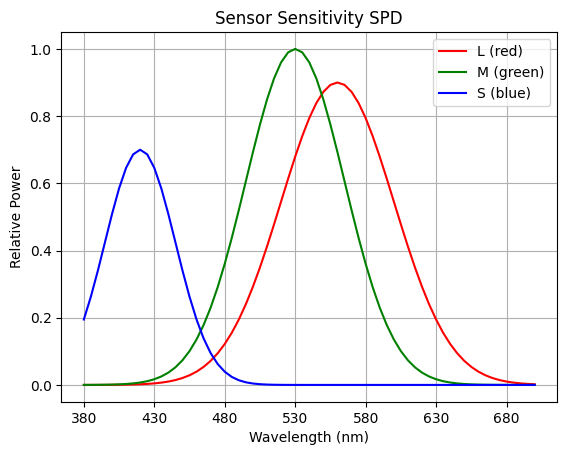

In [7]:
# Sensor sensitivities, simplification of the human eye
S = generate_sensor(wl)

# Plotting SPD's for the three cones
plot_sensor(wl, wl_min, wl_max, S)

So, with these three objects (illuminance, reflectance, sensor sensitivity), we can compute the sensor's response given a certain object is being lit under a certain light:

$\boldsymbol \rho = \Delta\lambda \cdot \mathbf{S^\top} diag(E)R$

Let's walk through this. Firstly, $\Delta\lambda$ represents our sampling width of wavelengths. In our case, it's $5$nm. $diag(E)$ is simply a square matrix with the vector $\mathbf e$ on its diagonal. As for some intuition: $diag(E)R$ is simply the $L$ vector we saw earlier, which represents the resultant light after being emitted from its illuminant and reflecting off our object. It's the linear algebra way of computing `E * R1` (element-wise vector multiplication) in Python. So, simplified:

$\boldsymbol \rho = \Delta\lambda \cdot \mathbf{S^\top}L$

Lastly, we matrix multiply our sensor sensitivites with the resultant light, and we get $\rho$, the sensor's output given an object and a light source. $\rho$ is a $1 \times k$ vector, and so the output is divided into the $k$ channels of the sensor. Again, for the human eye, we have three cones so $\rho$ would be $1 \times 3$. Let's code it!

In [8]:
delta = float(np.mean(np.diff(wl))) # Mean of the differences between the wavelengths, which should all be equal.
rho1 = delta * S.T @ L
print(rho1)

[49.76389492 52.70087256  9.31047356]


Now, for the real question:

**Given an illuminant, a sensor, and an object, how can we find another object that looks the same to the sensor as the first?** Written mathematically, here are our high-level constraints:

$\rho_{R_1} = \rho_{R_2}$, and $R_1 \neq R_2$

Since we want to focus only on the reflectances, let's rewrite our equation for $\rho$ as such:

$\rho = \mathbf A^\top R$, where $\mathbf A = \Delta\lambda\cdot diag(E)\mathbf S$

Let's expand it in code:

In [9]:
k = 3 # n sensors
n = len(wl)

A = delta * np.diag(E) @ S # A is an n x k matrix, 65 x 3 in our case

# In Z3, represent the second reflector
R2 = [Real(f"R2_{i}") for i in range(n)]

s = Solver()

# Make sure reflectances are between 0 and 1
for R2i in R2:
  s.add(And(0 <= R2i, R2i <= 1))

# Bonus: require that the reflectance curve doesn't jump around a bunch
# for i, R2i in enumerate(R2):
#   s.add(And(0 <= R2i, R2i <= 1))
#   if i > 0:
#     s.add(And(-.05 <= R2[i-1] - R2i, R2[i-1] - R2i <= .05))

# Make sure R2's rho is equal to R1's rho
# We'll have to do it manually without linear algebra notation
s.add(
      # Just doing the matrix multiplication, element by element
      Sum([A.T[0][i] * R2[i] for i in range(n)]) == rho1[0],
      Sum([A.T[1][i] * R2[i] for i in range(n)]) == rho1[1],
      Sum([A.T[2][i] * R2[i] for i in range(n)]) == rho1[2]
)

Did we find a metamer?

In [10]:
if s.check() == sat:
  print("Metamer found!")
else:
  print("No metamer found :(")

Metamer found!


Let's look at it as an array:

In [11]:
m = s.model()
R2_sol = np.zeros(len(wl))
for i, R2i in enumerate(R2):
  # Safely convert Z3 numeric reference to a Python float
  reflectance_val = m.eval(R2i)
  R2_sol[i] = float(reflectance_val.as_fraction())

R2_sol

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 1.        , 0.        ,
       1.        , 0.        , 1.        , 0.        , 1.        ,
       0.        , 0.        , 0.        , 0.50475753, 0.        ,
       1.        , 1.        , 0.        , 1.        , 1.        ,
       0.70688503, 0.        , 1.        , 0.        , 1.        ,
       1.        , 1.        , 1.        , 0.        , 1.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        , 1.        , 0.68937085, 1.        , 1.        ,
       0.        , 0.        , 1.        , 0.        , 1.        ,
       1.        , 0.        , 0.        , 0.        , 1.        ,
       1.        , 1.        , 0.        , 0.        , 1.        ,
       0.        , 1.        , 1.        , 0.        , 1.        ])

Let's see what the two objects' reflectance curves look like.

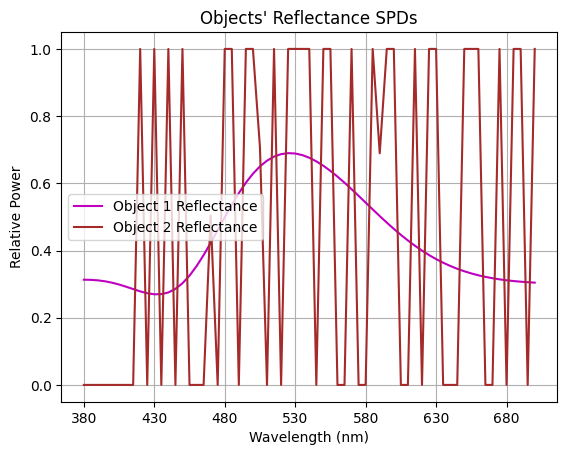

In [12]:
# Plotting the objects' reflectance SPD
plot_two_reflectants(wl, R1, R2_sol)

A weird looking object, isn't it? But:

In [13]:
print(f"R1 sensor values = {A.T @ R1}")
print(f"R2 sensor values = {A.T @ R2_sol}")
print(f"Sensor value difference = {(A.T @ R2_sol - A.T @ R1).round(8)}") # Round decimals to 8 places

R1 sensor values = [49.76389492 52.70087256  9.31047356]
R2 sensor values = [49.76389492 52.70087256  9.31047356]
Sensor value difference = [ 0. -0.  0.]


They'd look the same to us under the simulated light!

You have successfully demonstrated how constraint solvers can model non-trivial physical properties like metamerism. Feel free to tweak the simulated illuminant functions to see how the solver adapts the resulting objects!

####If you'd like to continue your Z3 journey, you can start with this guide to learn more:
https://ericpony.github.io/z3py-tutorial/guide-examples.htm